# Instance-Based vs Model-Based Learning

## Goal

Learn the difference between **remembering examples** and **learning a general rule**. By the end, you will be able to:

- explain instance-based and model-based learning in simple words;
- trace how each method trains and predicts;
- use the student **play-hours / study-hours / pass-fail** example;
- understand K-Nearest Neighbours (KNN), decision boundaries, storage, speed, and serialization;
- choose a suitable approach and answer common revision questions.

**Source material:** the supplied transcript and slides titled *Instance Based vs Model Based Learning*. Repetition and video filler have been removed; technical wording has been clarified.


## 1. The big idea

A machine-learning system uses past data to predict an answer for new data. The answer may be:

- a **number** — a regression problem, such as predicting a house price; or
- a **category** — a classification problem, such as predicting pass or fail.

There are two broad learning styles in this lesson:

| Learning style | Simple meaning | What happens when a new query arrives? |
|---|---|---|
| **Instance-based learning** | Keep the training examples and compare the new case with similar stored cases | Most of the work happens at prediction time |
| **Model-based learning** | Learn parameters or a rule that summarizes the pattern in the training data | Apply the learned rule to the new case |

Another common name for instance-based learning is **memory-based** or **lazy learning**. Model-based methods are often called **eager learning** because they do more work during training.

> Memory versus generalization is a useful intuition, but instance-based methods do more than blindly memorize: they use a comparison rule, such as distance and neighbour voting, to generalize locally.


## 2. Running example: will a student pass?

Suppose each student has two input features:

1. `play_hours` — hours spent playing;
2. `study_hours` — hours spent studying.

The target is `Pass` or `Fail`. In this simplified example, students who study more and play less are more likely to pass. Real data can contain **outliers**: for example, a student may study fewer hours and still pass.


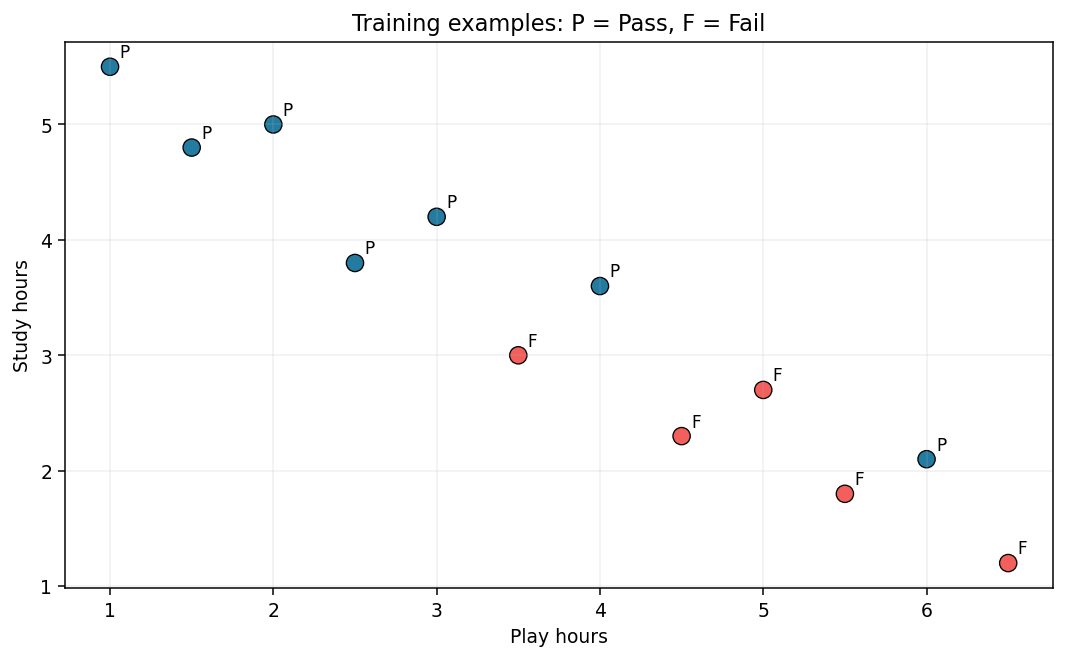

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# A small, deterministic teaching dataset
play_hours = np.array([1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5])
study_hours = np.array([5.5, 4.8, 5.0, 3.8, 4.2, 3.0, 3.6, 2.3, 2.7, 1.8, 2.1, 1.2])
labels = np.array(["Pass", "Pass", "Pass", "Pass", "Pass", "Fail", "Pass", "Fail", "Fail", "Fail", "Pass", "Fail"])

colors = np.where(labels == "Pass", "#247BA0", "#F25F5C")
plt.figure(figsize=(8, 5))
plt.scatter(play_hours, study_hours, c=colors, s=85, edgecolor="black", linewidth=0.7)
for x, y, label in zip(play_hours, study_hours, labels):
    plt.annotate(label[0], (x, y), xytext=(5, 5), textcoords="offset points", fontsize=9)
plt.xlabel("Play hours")
plt.ylabel("Study hours")
plt.title("Training examples: P = Pass, F = Fail")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


The points do not follow a perfect rule. That is normal. Machine learning looks for a useful pattern while accepting that noise and exceptions may exist.

## 3. Instance-based learning

An instance-based learner keeps the training examples. For a new student, it asks: **Which stored students are most similar to this student?**

K-Nearest Neighbours is the lesson's main example:

1. Choose `k`, the number of neighbours.
2. Measure the distance from the new point to every training point.
3. Select the `k` smallest distances.
4. For classification, let the neighbours vote. For regression, usually average their target values.

For two features, Euclidean distance is:

$$
d(\mathbf{x},\mathbf{q}) = \sqrt{(x_1-q_1)^2+(x_2-q_2)^2}
$$

Here, $\mathbf{q}$ is the new query and $\mathbf{x}$ is one stored training example.


In [2]:
training_features = np.column_stack([play_hours, study_hours])
query = np.array([4.8, 2.4])  # [play_hours, study_hours]
k = 3

distances = np.sqrt(np.sum((training_features - query) ** 2, axis=1))
nearest_indices = np.argsort(distances)[:k]
nearest_labels = labels[nearest_indices]
prediction = max(set(nearest_labels), key=list(nearest_labels).count)

print("New student [play, study]:", query)
print("Nearest row indices:", nearest_indices.tolist())
print("Nearest distances:", np.round(distances[nearest_indices], 3).tolist())
print("Neighbour labels:", nearest_labels.tolist())
print("KNN prediction:", prediction)


New student [play, study]: [4.8 2.4]
Nearest row indices: [7, 8, 9]
Nearest distances: [0.316, 0.361, 0.922]
Neighbour labels: ['Fail', 'Fail', 'Fail']
KNN prediction: Fail


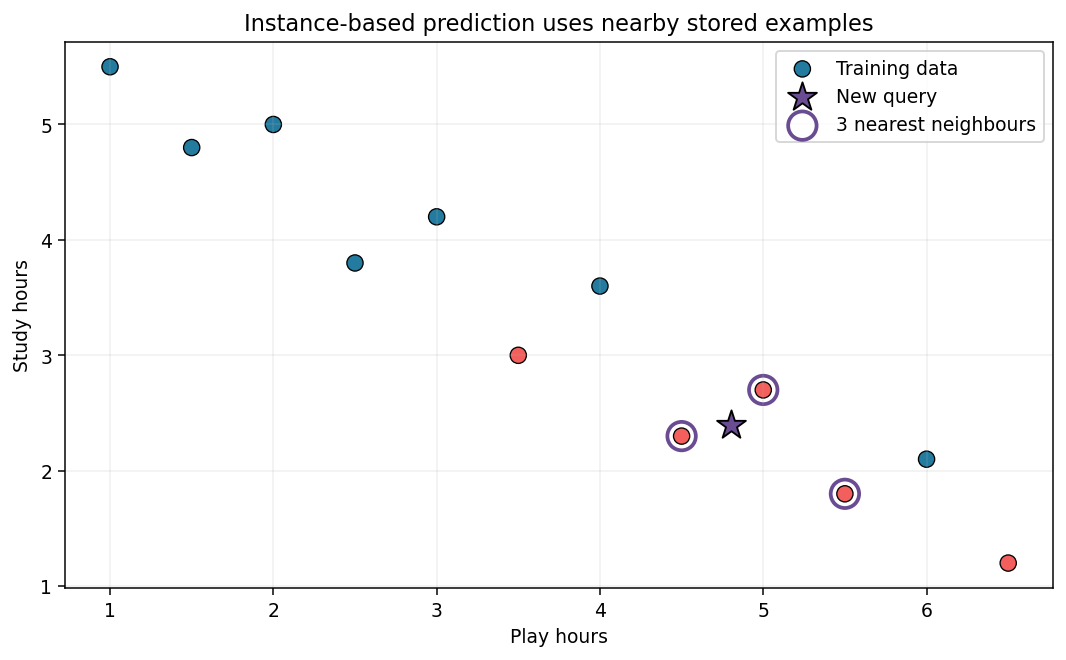

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(play_hours, study_hours, c=colors, s=75, edgecolor="black", linewidth=0.7, label="Training data")
plt.scatter(*query, marker="*", s=260, c="#6A4C93", edgecolor="black", label="New query")
plt.scatter(play_hours[nearest_indices], study_hours[nearest_indices], s=230,
            facecolors="none", edgecolors="#6A4C93", linewidths=2, label=f"{k} nearest neighbours")
plt.xlabel("Play hours")
plt.ylabel("Study hours")
plt.title("Instance-based prediction uses nearby stored examples")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()


### What is learned?

There may be little or no fitted global equation. The essential stored information is:

- the training examples and labels;
- the distance rule;
- settings such as `k` and the voting method.

Pattern discovery is therefore **postponed until a query arrives**. This gives instance-based learning its name *lazy learning*.

### Main consequences

- **Training is usually fast:** storing data may be most of the training work.
- **Prediction can be slow:** a query may be compared with many stored rows.
- **Storage can be large:** the training set must usually remain available.
- **Local patterns can be captured:** the answer can adapt to the nearby region of the feature space.
- **Scaling matters:** a feature with large numeric values can dominate Euclidean distance.


## 4. Model-based learning

A model-based method uses training data to estimate **parameters**. Those parameters define a general rule or **decision function**.

For the student example, a simple teaching rule could be:

$$
\text{score} = \text{study hours} - \text{play hours} + 1
$$

- If `score >= 0`, predict `Pass`.
- If `score < 0`, predict `Fail`.

The set of points where `score = 0` is the **decision boundary**. The boundary separates the regions assigned to the two classes. A real model learns its coefficients from data; the coefficients below are deliberately simple so the idea stays visible.


Model score: -1.4
Model-based prediction: Fail


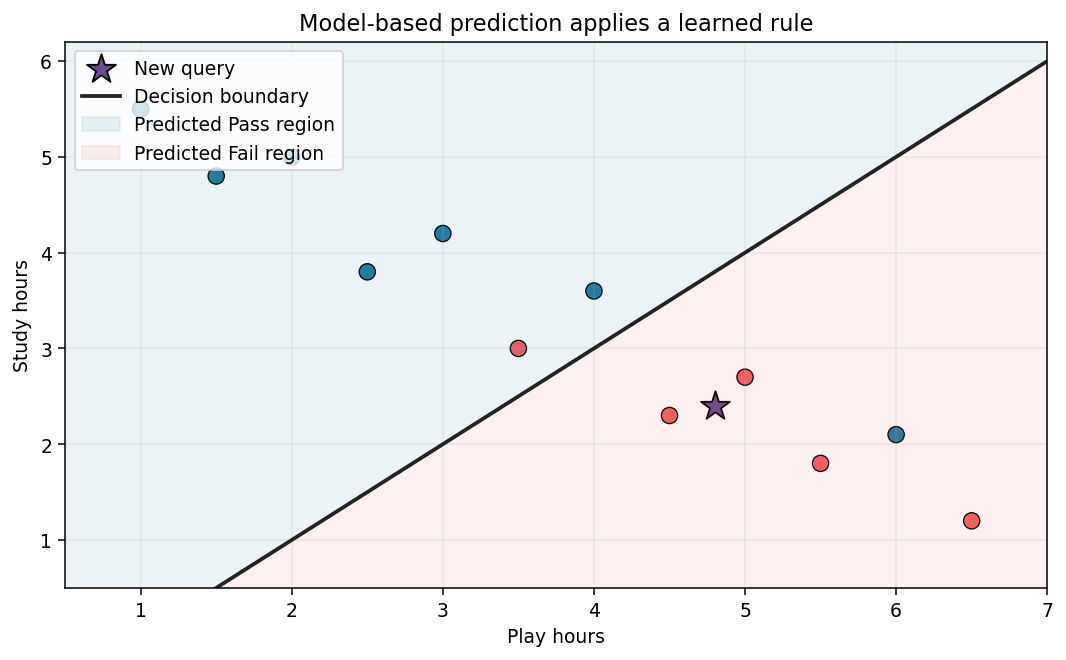

In [4]:
def model_score(play, study):
    return study - play + 1.0

model_prediction = "Pass" if model_score(*query) >= 0 else "Fail"
print("Model score:", round(model_score(*query), 2))
print("Model-based prediction:", model_prediction)

x_line = np.linspace(0.5, 7.0, 200)
y_boundary = x_line - 1.0  # score = study - play + 1 = 0

plt.figure(figsize=(8, 5))
plt.scatter(play_hours, study_hours, c=colors, s=75, edgecolor="black", linewidth=0.7)
plt.scatter(*query, marker="*", s=260, c="#6A4C93", edgecolor="black", label="New query")
plt.plot(x_line, y_boundary, color="#222222", linewidth=2, label="Decision boundary")
plt.fill_between(x_line, y_boundary, 6.2, color="#247BA0", alpha=0.09, label="Predicted Pass region")
plt.fill_between(x_line, 0.5, y_boundary, color="#F25F5C", alpha=0.09, label="Predicted Fail region")
plt.xlim(0.5, 7.0)
plt.ylim(0.5, 6.2)
plt.xlabel("Play hours")
plt.ylabel("Study hours")
plt.title("Model-based prediction applies a learned rule")
plt.grid(alpha=0.2)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


### Training and prediction workflow

**During training**

1. Prepare the data.
2. Choose a model form, such as a line, tree, or neural network.
3. Estimate parameters from the training data.
4. Check performance using validation/test data.
5. Save the fitted parameters and required preprocessing.

**During prediction**

1. Apply the same preprocessing to the new row.
2. Pass it through the saved model.
3. Convert the model output into the required number or class.

After training, the original rows are not normally needed for ordinary inference. However, they may still be needed for auditing, retraining, debugging, drift checks, legal duties, or reproducibility. Do not delete valuable source data merely because a fitted model exists.


## 5. What does it mean to save a model?

A fitted model can be **serialized**: its parameters and structure are converted into bytes that can be stored and loaded later. Common formats depend on the library and model type; examples include Pickle/joblib for Python objects and HDF5 (`.h5`) for some deep-learning workflows.

The transcript's key idea is correct: the saved object contains the fitted rule or parameters, so prediction does not have to repeat training.

> Security note: never load an untrusted Pickle file. Pickle can run code while loading.


In [5]:
import pickle

# A tiny model represented by parameters, not by all training rows
saved_model = {
    "feature_order": ["play_hours", "study_hours"],
    "weights": [-1.0, 1.0],
    "intercept": 1.0,
    "threshold": 0.0,
}

serialized = pickle.dumps(saved_model)
restored_model = pickle.loads(serialized)  # Safe here only because we created it ourselves

print("Serialized size:", len(serialized), "bytes")
print("Restored parameters:", restored_model)


Serialized size: 137 bytes
Restored parameters: {'feature_order': ['play_hours', 'study_hours'], 'weights': [-1.0, 1.0], 'intercept': 1.0, 'threshold': 0.0}


## 6. Side-by-side comparison

| Question | Instance-based learning | Model-based learning |
|---|---|---|
| What represents learning? | Stored examples plus a similarity rule | Learned parameters and model structure |
| When is most work done? | At prediction time | At training time |
| Is there an explicit fitted model? | Often no global model | Usually yes |
| What is used for a new prediction? | Training instances directly | The fitted rule/function |
| Typical training speed | Fast | Can be slower |
| Typical prediction speed | Can be slower | Often fast |
| Typical storage | Can be high because examples are retained | Often lower, but large models can still be huge |
| Can old training rows be discarded for inference? | Usually no | Usually yes |
| Pattern learned | Local, near the query | Global or structured pattern, depending on model |
| Examples | KNN, kernel regression, case-based reasoning | Linear/logistic regression, decision trees, neural networks, SVMs |

These are tendencies, not absolute laws. Indexing can make neighbour search fast, while a very large neural network can be slower and larger than a small KNN dataset.


## 7. From basic to advanced: important practical ideas

### Feature scaling

If annual income is measured in rupees while age is measured in years, income may dominate a distance calculation. Standardization puts features on comparable scales.

### Choosing `k`

- A very small `k` is sensitive to noise and outliers.
- A very large `k` can smooth away useful local structure.
- Choose `k` using validation data rather than guessing.

### Curse of dimensionality

As the number of features grows, points can all appear far apart. Neighbour-based similarity becomes less informative unless features are selected, transformed, or supported by enough data.

### Bias and variance intuition

- A flexible local learner with small `k` can have **low bias but high variance**.
- A model with an overly simple global boundary can have **high bias** and underfit.

### Model-based does not automatically mean better

The transcript presents generalization as better than memorization. A safer conclusion is: **the better approach depends on the data, latency, memory, explainability, and accuracy requirements.** KNN can work very well on small, well-scaled datasets; a fitted model is often preferable when fast inference is essential.


## 8. Worked decision checklist

Use an instance-based method when:

- the dataset is small enough to store and search;
- nearby examples are naturally meaningful;
- the pattern is highly local or changes often;
- quick training matters more than quick prediction.

Use a model-based method when:

- predictions must be fast or run on a small device;
- the training set is too large to search for every query;
- you want a compact rule or learned parameters;
- a suitable model form can capture the pattern.

In either case, evaluate on unseen data. A method is not genuinely useful merely because it fits the training data.


## 9. Quick revision sheet

- **Instance:** one training example.
- **Feature:** an input variable, such as study hours.
- **Target/label:** the answer to predict, such as Pass or Fail.
- **Instance-based learning:** predicts from similar stored examples.
- **KNN:** votes or averages using the `k` nearest examples.
- **Model-based learning:** estimates parameters that describe a reusable rule.
- **Decision function:** produces a score or output from input features.
- **Decision boundary:** points where the predicted class changes.
- **Generalization:** performing well on new, unseen data.
- **Serialization:** saving a fitted object or its parameters for later use.
- **Lazy learning:** most computation is delayed until prediction.
- **Eager learning:** a model is fitted before queries arrive.


## 10. Quick questions — try before opening the answers

1. What is the central difference between instance-based and model-based learning?
2. Is pass/fail prediction regression or classification?
3. What information does KNN use to classify a new point?
4. Why must an instance-based system usually keep its training data?
5. Why can KNN prediction be slow?
6. What is a decision boundary?
7. In which approach is pattern discovery mainly postponed until a query arrives?
8. What does model serialization mean?
9. Can training data always be safely deleted after a model is trained?
10. Why should features be scaled before Euclidean-distance KNN?
11. What risk comes with a very small value of `k`?
12. Is model-based learning always better? Explain briefly.

### Mini practice

13. The three nearest labels are `Pass, Fail, Pass`. What does ordinary KNN predict?
14. A system must answer millions of requests quickly on a phone. Which style is usually more suitable, assuming a compact accurate model can be trained?
15. A new labelled example is added every minute and training must remain almost instant. Which style may be attractive?


## 11. Answer key

1. Instance-based learning predicts by comparing with stored examples; model-based learning applies a fitted rule or parameters.
2. Classification, because the output is a category.
3. A distance/similarity measure, the nearest stored examples, `k`, and a voting rule.
4. The examples are directly needed to compare with each new query.
5. It may calculate distances to many training rows and sort/search them for every query.
6. The set of input points where the model changes from one predicted class to another.
7. Instance-based learning.
8. Converting the fitted structure and parameters into a storable form that can be loaded later.
9. No. It may be unnecessary for ordinary inference, but still necessary for retraining, audit, debugging, or governance.
10. Otherwise a feature with a larger numeric scale can dominate the distance.
11. High sensitivity to noise or outliers; this is high-variance behaviour.
12. No. The best method depends on the dataset and requirements such as accuracy, latency, storage, and update frequency.
13. `Pass`, because it has two of the three votes.
14. Model-based learning is usually more suitable because inference can use a compact pre-fitted rule.
15. Instance-based learning may be attractive because adding a stored example can be much cheaper than retraining a model.
